# 01 — Análise Exploratória dos Dados (EDA)

**Tech Challenge Fase 02 — Sistema de Recomendação (Instacart)**

Análise exploratória das tabelas do Instacart para entender os dados antes da
modelagem: formato, qualidade, distribuições e os sinais disponíveis para um
sistema de recomendação.

**Roteiro:**
1. Carregamento das 6 tabelas e esquema relacional.
2. Visão geral (dimensões, tipos, nulos) de cada tabela.
3. Pedidos: `eval_set`, usuários, frequência e padrões temporais.
4. Catálogo: produtos, corredores (*aisles*) e departamentos.
5. Itens dos pedidos: tamanho da cesta e reordenação (sinal-alvo).
6. Matriz usuário-item e esparsidade.
7. Conclusões e implicações para a modelagem.

## 0. Setup

Importação de bibliotecas, fixação de *seeds* (reprodutibilidade) e localização
da pasta de dados subindo a árvore de diretórios até o `pyproject.toml`, para o
notebook funcionar independentemente do diretório de execução.

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Reprodutibilidade: fixar as seeds faz amostragens/operacoes aleatorias
# darem sempre o mesmo resultado.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Exibicao mais confortavel
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
plt.rcParams['figure.figsize'] = (9, 4)


def find_project_root(marker: str = 'pyproject.toml') -> Path:
    '''Sobe na arvore de diretorios ate encontrar o marcador do projeto.'''
    current = Path.cwd()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f'Nao encontrei {marker} a partir de {current}')


PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
print('Project root :', PROJECT_ROOT)
print('Raw data dir :', RAW_DIR)
print('Arquivos     :', [p.name for p in sorted(RAW_DIR.glob('*.csv'))])

Project root : c:\Users\erick\projetos\mlp-market-recommender-system
Raw data dir : c:\Users\erick\projetos\mlp-market-recommender-system\data\raw
Arquivos     : ['aisles.csv', 'departments.csv', 'order_products__prior.csv', 'order_products__train.csv', 'orders.csv', 'products.csv']


## 1. Carregamento dos dados

Os CSVs são lidos com tipos (`dtype`) reduzidos para economizar memória — o
`order_products__prior.csv` tem ~32 milhões de linhas (~550 MB).

Esquema relacional:
- `orders`: liga `user_id` ↔ `order_id` e traz informação temporal.
- `order_products__*`: produtos contidos em cada pedido.
- `products` → `aisles` / `departments`: catálogo e categorias.

In [2]:
op_dtypes = {
    'order_id': 'int32',
    'product_id': 'int32',
    'add_to_cart_order': 'int16',
    'reordered': 'int8',
}
orders_dtypes = {
    'order_id': 'int32',
    'user_id': 'int32',
    'eval_set': 'category',
    'order_number': 'int16',
    'order_dow': 'int8',
    'order_hour_of_day': 'int8',
    'days_since_prior_order': 'float32',
}

aisles = pd.read_csv(RAW_DIR / 'aisles.csv')
departments = pd.read_csv(RAW_DIR / 'departments.csv')
products = pd.read_csv(RAW_DIR / 'products.csv')
orders = pd.read_csv(RAW_DIR / 'orders.csv', dtype=orders_dtypes)
order_products_train = pd.read_csv(
    RAW_DIR / 'order_products__train.csv', dtype=op_dtypes
)
order_products_prior = pd.read_csv(
    RAW_DIR / 'order_products__prior.csv', dtype=op_dtypes
)

print('aisles      ', aisles.shape)
print('departments ', departments.shape)
print('products    ', products.shape)
print('orders      ', orders.shape)
print('op_train    ', order_products_train.shape)
print('op_prior    ', order_products_prior.shape)

aisles       (134, 2)
departments  (21, 2)
products     (49688, 4)
orders       (3421083, 7)
op_train     (1384617, 4)
op_prior     (32434489, 4)


## 2. Visão geral das tabelas

Checagem inicial de cada tabela: dimensões, uso de memória e valores nulos.

In [3]:
def overview(name: str, df: pd.DataFrame) -> None:
    '''Imprime um resumo rapido de uma tabela.'''
    mem_mb = df.memory_usage(deep=True).sum() / 1024**2
    print(f'=== {name} | shape={df.shape} | {mem_mb:.1f} MB ===')
    nulls = df.isna().sum()
    print('nulos por coluna:')
    print(nulls[nulls > 0] if nulls.any() else '  (nenhum)')
    print('-' * 50)


for nm, d in [
    ('aisles', aisles),
    ('departments', departments),
    ('products', products),
    ('orders', orders),
    ('order_products_train', order_products_train),
    ('order_products_prior', order_products_prior),
]:
    overview(nm, d)

=== aisles | shape=(134, 2) | 0.0 MB ===
nulos por coluna:
  (nenhum)
--------------------------------------------------
=== departments | shape=(21, 2) | 0.0 MB ===
nulos por coluna:
  (nenhum)
--------------------------------------------------
=== products | shape=(49688, 4) | 4.9 MB ===
nulos por coluna:
  (nenhum)
--------------------------------------------------
=== orders | shape=(3421083, 7) | 55.5 MB ===
nulos por coluna:
days_since_prior_order    206209
dtype: int64
--------------------------------------------------
=== order_products_train | shape=(1384617, 4) | 14.5 MB ===
nulos por coluna:
  (nenhum)
--------------------------------------------------
=== order_products_prior | shape=(32434489, 4) | 340.3 MB ===
nulos por coluna:
  (nenhum)
--------------------------------------------------


In [4]:
# Espiando as primeiras linhas das tabelas principais
display(orders.head())
display(products.head())
display(order_products_prior.head())

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


## 3. Pedidos (`orders`)

A coluna `eval_set` define uma divisão temporal por usuário:
- `prior`: histórico de pedidos do usuário.
- `train` / `test`: o último pedido do usuário (cada usuário em um dos dois).

Treinar com `prior` e avaliar no `train` reproduz o uso real do recomendador e
evita vazamento de dados (*data leakage*).

In [5]:
print('Pedidos por eval_set:')
print(orders['eval_set'].value_counts())
print('\nUsuarios unicos por eval_set:')
print(orders.groupby('eval_set', observed=True)['user_id'].nunique())
print('\nUsuarios unicos no total:', orders['user_id'].nunique())

Pedidos por eval_set:
eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

Usuarios unicos por eval_set:
eval_set
prior    206209
test      75000
train    131209
Name: user_id, dtype: int64

Usuarios unicos no total: 206209


count    206209.000000
mean         16.590367
std          16.654774
min           4.000000
25%           6.000000
50%          10.000000
75%          20.000000
max         100.000000
Name: order_number, dtype: float64


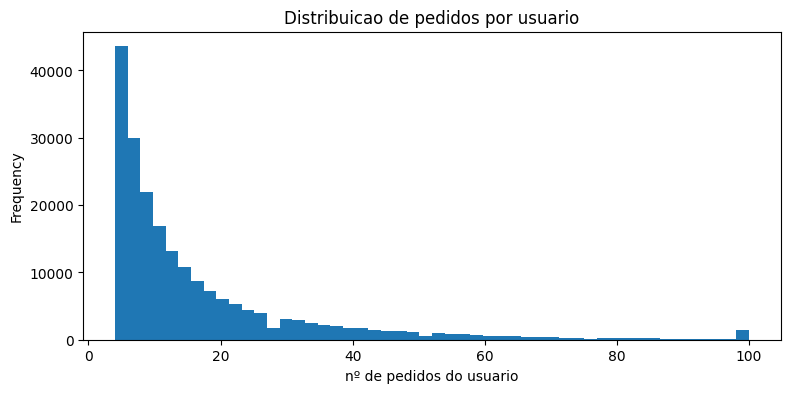

In [6]:
# Quantos pedidos cada usuario tem? (order_number e a posicao na sequencia)
orders_per_user = orders.groupby('user_id')['order_number'].max()
print(orders_per_user.describe())

orders_per_user.plot(
    kind='hist', bins=50, title='Distribuicao de pedidos por usuario'
)
plt.xlabel('nº de pedidos do usuario')
plt.show()

### Padrões temporais

Quando as pessoas compram? Dia da semana (`order_dow`, 0 = domingo) e hora do
dia (`order_hour_of_day`). Esses padrões podem virar **features** mais tarde.

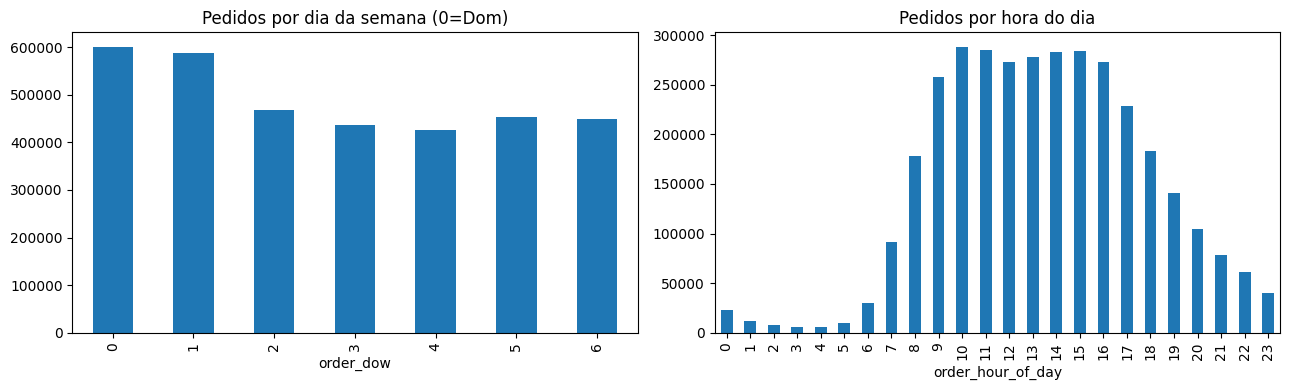

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
orders['order_dow'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], title='Pedidos por dia da semana (0=Dom)'
)
orders['order_hour_of_day'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], title='Pedidos por hora do dia'
)
plt.tight_layout()
plt.show()

### Mapa de calor: dia × hora

Cruzamento dos dois eixos temporais numa só visão. O mapa de calor revela a
interação entre dia e horário (concentração em certos dias e faixas do dia) que
as barras isoladas não capturam.

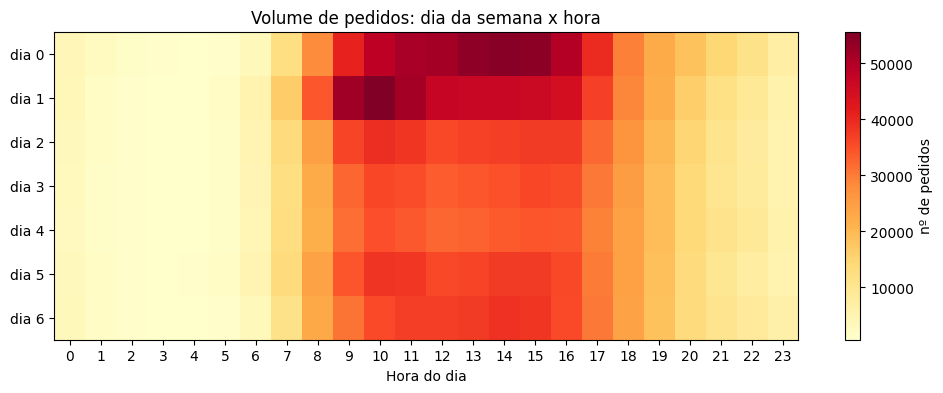

In [8]:
# Visao combinada dia x hora (complementa as barras acima)
heat = (
    orders.groupby(['order_dow', 'order_hour_of_day']).size().unstack(fill_value=0)
)
fig, ax = plt.subplots(figsize=(12, 4))
image = ax.imshow(heat.values, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(heat.shape[0]))
ax.set_yticklabels([f'dia {d}' for d in heat.index])
ax.set_xticks(range(0, 24))
ax.set_xticklabels(range(0, 24))
ax.set_xlabel('Hora do dia')
ax.set_title('Volume de pedidos: dia da semana x hora')
fig.colorbar(image, ax=ax, label='nº de pedidos')
plt.show()

### Intervalo entre pedidos

`days_since_prior_order`: dias desde o pedido anterior (capado em 30). O primeiro
pedido de cada usuário é nulo por definição — origem dos nulos vistos na seção 2.

Nulos em days_since_prior_order: 206209
(deve bater com o nº de usuarios, pois e o 1º pedido de cada um)


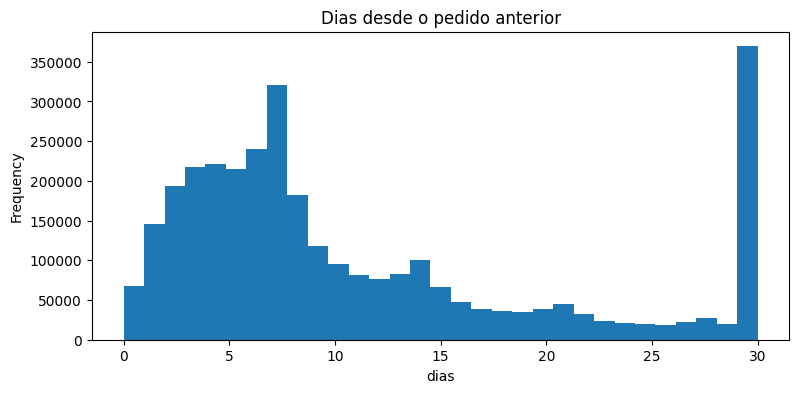

In [9]:
n_nulos = orders['days_since_prior_order'].isna().sum()
print('Nulos em days_since_prior_order:', n_nulos)
print('(deve bater com o nº de usuarios, pois e o 1º pedido de cada um)')

orders['days_since_prior_order'].plot(
    kind='hist', bins=31, title='Dias desde o pedido anterior'
)
plt.xlabel('dias')
plt.show()

## 4. Catálogo: produtos, aisles e departments

Junção de `products` com `aisles` e `departments` para descrever a estrutura de
categorias do e-commerce.

Produtos: 49688
Departments: 21
Aisles: 134


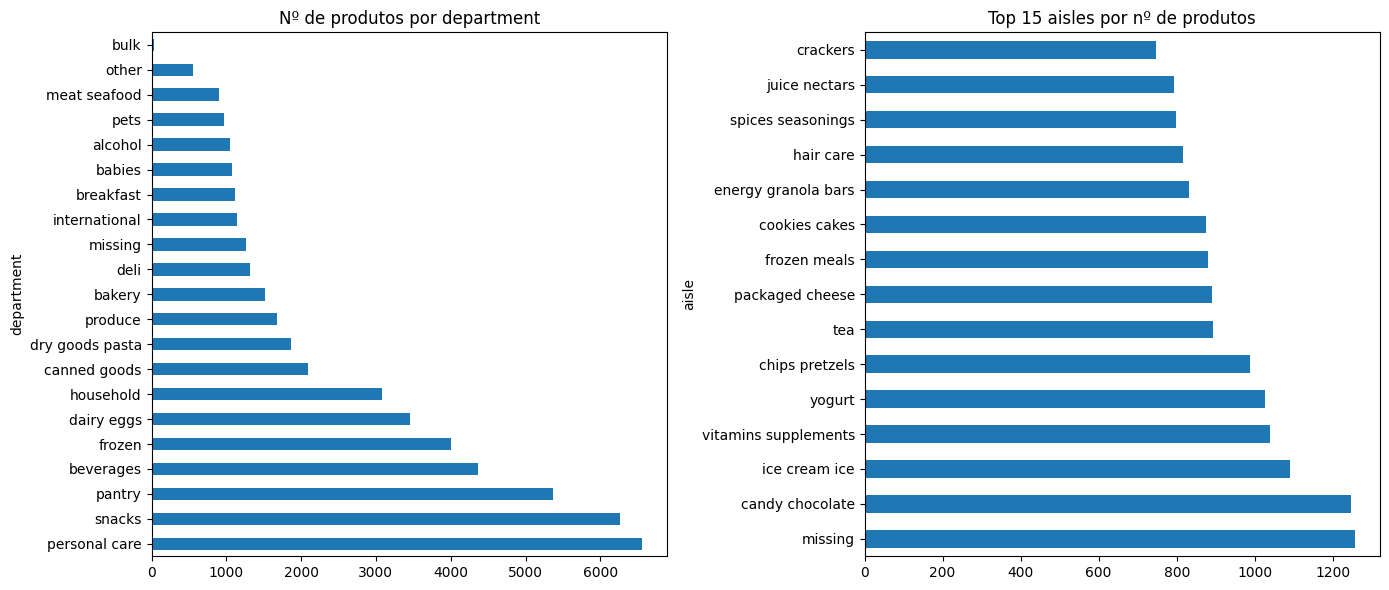

In [10]:
products_full = products.merge(aisles, on='aisle_id', how='left').merge(
    departments, on='department_id', how='left'
)
print('Produtos:', products_full.shape[0])
print('Departments:', products_full['department'].nunique())
print('Aisles:', products_full['aisle'].nunique())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
products_full['department'].value_counts().plot(
    kind='barh', ax=axes[0], title='Nº de produtos por department'
)
products_full['aisle'].value_counts().head(15).plot(
    kind='barh', ax=axes[1], title='Top 15 aisles por nº de produtos'
)
plt.tight_layout()
plt.show()

### Volume de vendas por departamento

O gráfico acima mostra **quantos produtos** cada departamento tem no catálogo
(oferta). Aqui medimos **quanto cada departamento realmente vende** (demanda),
somando os itens comprados no histórico — perspectivas diferentes e
complementares.

,department,items_sold
0,produce,9479291
1,dairy eggs,5414016
2,snacks,2887550
3,beverages,2690129
4,frozen,2236432
5,pantry,1875577
6,bakery,1176787
7,canned goods,1068058
8,deli,1051249
9,dry goods pasta,866627


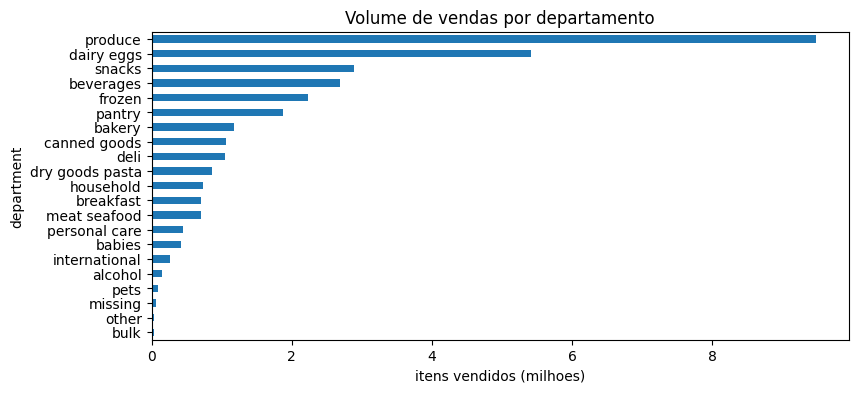

In [11]:
# Volume de VENDAS por departamento (demanda), complementando o nº de
# produtos por department (oferta/catalogo) mostrado acima.
prod_to_dept = products.set_index('product_id')['department_id']
dept_sales = (
    order_products_prior['product_id']
    .map(prod_to_dept)
    .value_counts()
    .rename_axis('department_id')
    .reset_index(name='items_sold')
    .merge(departments, on='department_id')
    .sort_values('items_sold', ascending=False)
)
display(dept_sales[['department', 'items_sold']].head(10))

dept_sales.set_index('department')['items_sold'].div(1e6).sort_values().plot(
    kind='barh', title='Volume de vendas por departamento'
)
plt.xlabel('itens vendidos (milhoes)')
plt.show()

## 5. Itens dos pedidos — cesta e reordenação

- **Tamanho da cesta**: itens por pedido (maior `add_to_cart_order`).
- **`reordered`**: 1 quando o produto já havia sido comprado antes pelo usuário.
  A média é a taxa de reordenação e constitui o sinal-alvo do modelo.

count    3.214874e+06
mean     1.008888e+01
std      7.525398e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.450000e+02
Name: add_to_cart_order, dtype: float64


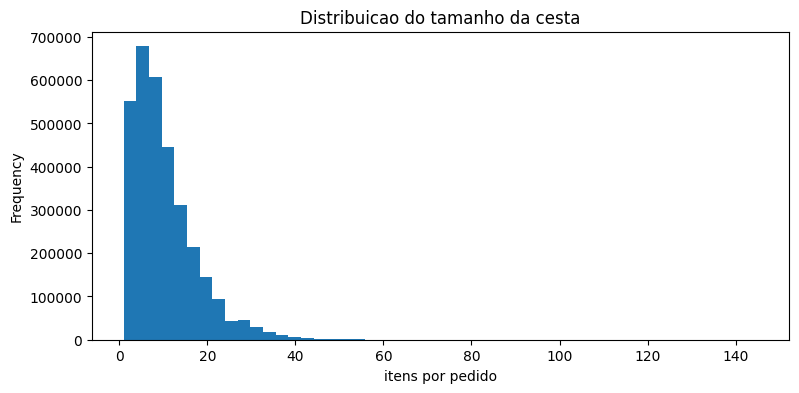

In [12]:
# Tamanho da cesta = maior add_to_cart_order de cada pedido (no historico prior)
basket_size = order_products_prior.groupby('order_id')['add_to_cart_order'].max()
print(basket_size.describe())

basket_size.plot(
    kind='hist', bins=50, title='Distribuicao do tamanho da cesta'
)
plt.xlabel('itens por pedido')
plt.show()

In [13]:
reorder_rate = order_products_prior['reordered'].mean()
print(f'Taxa global de reordenacao: {reorder_rate:.1%}')

# Produtos com maior taxa de recompra (entre os comprados >= 1000 vezes,
# para evitar produtos raros com taxa enganosa)
top_reordered = (
    order_products_prior.groupby('product_id')['reordered']
    .agg(['mean', 'count'])
    .query('count >= 1000')
    .sort_values('mean', ascending=False)
    .head(15)
    .reset_index()
    .merge(products[['product_id', 'product_name']], on='product_id')
)
top_reordered

Taxa global de reordenacao: 59.0%


,product_id,mean,count,product_name
0,9292,0.861691,2921,Half And Half Ultra Pasteurized
1,45504,0.860233,9108,Whole Organic Omega 3 Milk
2,43394,0.859030,8477,Organic Lactose Free Whole Milk
3,5514,0.857683,3970,Organic Homogenized Whole Milk
4,47231,0.857623,1489,Ultra-Purified Water
5,29447,0.854342,20198,"Milk, Organic, Vitamin D"
6,38689,0.850686,35663,Organic Reduced Fat Milk
7,34197,0.849952,5185,Goat Milk
8,24852,0.843501,472565,Banana
9,31720,0.841191,9842,Organic Whole Milk


In [14]:
# Produtos mais comprados (referencia para o baseline de POPULARIDADE).
top_products = (
    order_products_prior['product_id'].value_counts().head(15).reset_index()
)
top_products.columns = ['product_id', 'n_purchases']
top_products = top_products.merge(
    products[['product_id', 'product_name']], on='product_id'
)
top_products

,product_id,n_purchases,product_name
0,24852,472565,Banana
1,13176,379450,Bag of Organic Bananas
2,21137,264683,Organic Strawberries
3,21903,241921,Organic Baby Spinach
4,47209,213584,Organic Hass Avocado
5,47766,176815,Organic Avocado
6,47626,152657,Large Lemon
7,16797,142951,Strawberries
8,26209,140627,Limes
9,27845,137905,Organic Whole Milk


### Taxa de recompra por departamento

Conecta o sinal-alvo (`reordered`) às categorias: departamentos de **hábito**
(alta recompra, ex.: laticínios, bebidas, hortifrúti) vs. de **descoberta**
(baixa recompra, ex.: cuidado pessoal, mercearia seca). Útil como ideia de
feature por categoria.

,department,reorder_rate
15,dairy eggs,0.669969
6,beverages,0.653460
3,produce,0.649913
2,bakery,0.628141
19,deli,0.607719
7,pets,0.601285
17,babies,0.578971
9,bulk,0.577040
18,snacks,0.574180
4,alcohol,0.569924


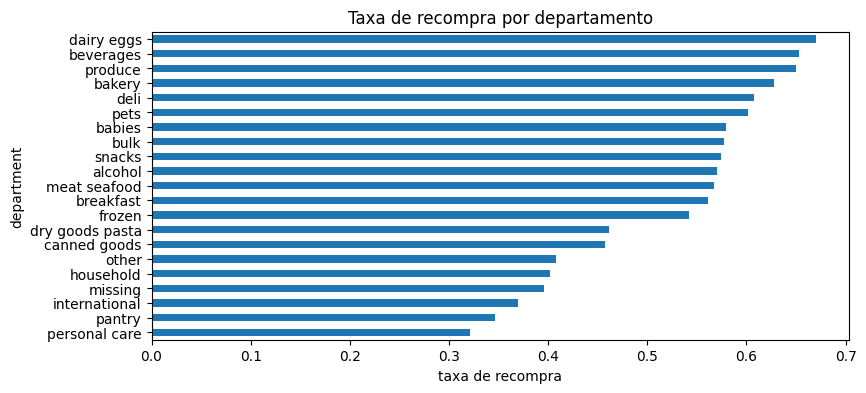

In [15]:
# Taxa de recompra por DEPARTAMENTO: liga o sinal-alvo (reordered) as categorias.
prod_to_dept = products.set_index('product_id')['department_id']
dept_reorder = (
    pd.DataFrame(
        {
            'department_id': order_products_prior['product_id'].map(prod_to_dept),
            'reordered': order_products_prior['reordered'],
        }
    )
    .groupby('department_id')['reordered']
    .mean()
    .rename('reorder_rate')
    .reset_index()
    .merge(departments, on='department_id')
    .sort_values('reorder_rate', ascending=False)
)
display(dept_reorder[['department', 'reorder_rate']])

dept_reorder.set_index('department')['reorder_rate'].sort_values().plot(
    kind='barh', title='Taxa de recompra por departamento'
)
plt.xlabel('taxa de recompra')
plt.show()

## 6. Matriz usuário-item e esparsidade

A interação relevante para recomendação é o par (usuário, produto). Como o
`user_id` está em `orders` e os produtos em `order_products`, é necessário juntar
as tabelas pelo `order_id`.

A esparsidade indica a fração de pares (usuário × produto) que nunca ocorreram —
tipicamente altíssima em recomendação, o que motiva o uso de *embeddings*.

> Nota: o merge de ~32 mi de linhas consome vários GB de RAM. Em máquinas
> limitadas, amostrar usuários antes.

In [16]:
prior = order_products_prior.merge(
    orders[['order_id', 'user_id']], on='order_id', how='left'
)

n_events = len(prior)
n_users = prior['user_id'].nunique()
n_items = prior['product_id'].nunique()
n_pairs = prior[['user_id', 'product_id']].drop_duplicates().shape[0]

print(f'Eventos (linhas)          : {n_events:,}')
print(f'Usuarios                  : {n_users:,}')
print(f'Produtos                  : {n_items:,}')
print(f'Pares unicos (user, item) : {n_pairs:,}')

sparsity = 1 - n_pairs / (n_users * n_items)
print(f'Esparsidade da matriz user-item: {sparsity:.4%}')
print(f'Media de produtos distintos por usuario: {n_pairs / n_users:.1f}')

Eventos (linhas)          : 32,434,489
Usuarios                  : 206,209
Produtos                  : 49,677
Pares unicos (user, item) : 13,307,953
Esparsidade da matriz user-item: 99.8701%
Media de produtos distintos por usuario: 64.5


## 7. Conclusões e implicações para a modelagem

Resumo do que o EDA nos diz e como isso guia as próximas etapas:

- **Volume é abundante** (~32M interações no histórico) — folgado para treinar
  uma rede neural e muito acima do mínimo de 10k exigido.
- **Feedback implícito**: sem ratings; o sinal é compra/recompra. A coluna
  **`reordered`** é o alvo natural.
- **Matriz muito esparsa** → usar **embeddings** de usuário e produto na MLP
  (Neural Collaborative Filtering), não one-hot.
- **Divisão temporal pronta** (`prior` → `train`): treinar no histórico e
  avaliar no "próximo pedido", sem vazamento de dados.
- **Features candidatas**: padrões de dia/hora, intervalo entre pedidos,
  tamanho de cesta, taxa de reorder por usuário e por produto, departamento/aisle.
- **Baselines** (sklearn) para comparação: popularidade global e taxa de reorder.

**Próximos passos (Etapa 1 → 3):** mover esta lógica de leitura/limpeza para
módulos em `src/` (clean code + design patterns), e transformá-la nos estágios
do pipeline DVC: `preprocess → feature_eng → train → evaluate`.